# Group 5 — MNIST Image Classification

## Neural Network Development and Evaluation

**Project goal:** Develop and compare multiple CNN architectures, achieve greater than 99% validation accuracy, retrain the best-performing architecture on the complete MNIST training set, and evaluate its performance on the test set.

## 0. Setup & Imports

Import the required packages, set random seeds, and confirm the TensorFlow and GPU configuration.

In [ ]:
# Import the packages needed for model training and evaluation

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

# Use the same random seed to make results more reproducible
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Confirm the TensorFlow version and GPU connection
print("TensorFlow version:", tf.__version__)
print("Available GPU:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
Available GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Load MNIST Data

Load the MNIST dataset (train/test split) and inspect shapes.

In [ ]:
# Load the MNIST handwritten-digit dataset

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Display the dataset dimensions
print("Training images shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test images shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

# Display the pixel-value range before normalization
print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)
Minimum pixel value: 0
Maximum pixel value: 255


## 2. Data Exploration & Preprocessing

Visualize sample digits, normalize pixel values (0-1), reshape for CNN input (add channel dimension).

### 2.1 Sample MNIST Digits

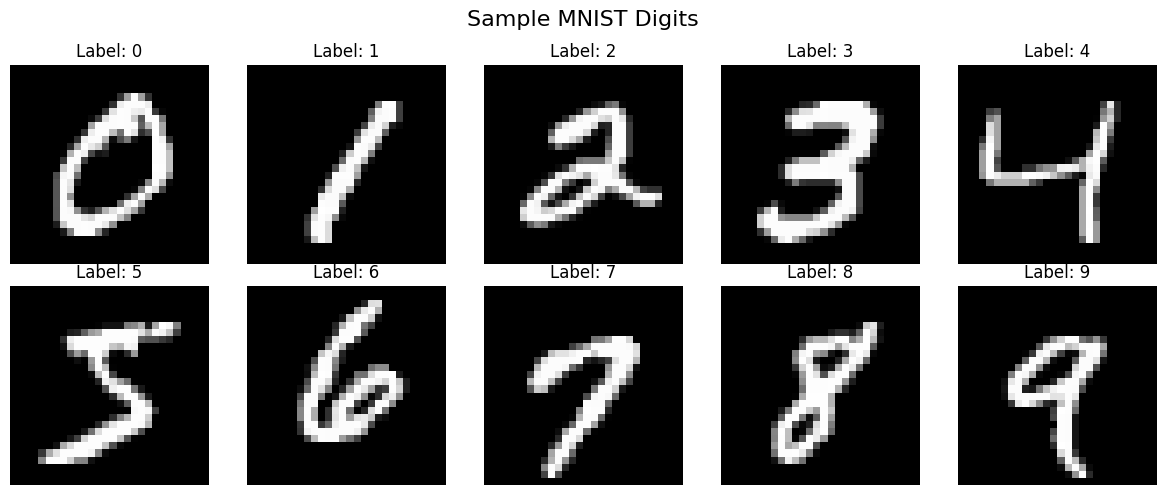

In [ ]:
# Display one training example for each digit from 0 to 9

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for digit, ax in enumerate(axes.ravel()):
    image_index = np.where(y_train == digit)[0][0]

    ax.imshow(x_train[image_index], cmap="gray")
    ax.set_title(f"Label: {digit}")
    ax.axis("off")

plt.suptitle("Sample MNIST Digits", fontsize=16)
plt.tight_layout()

# Save this image for the project webpage
plt.savefig("mnist_sample_digits.png", dpi=300, bbox_inches="tight")
plt.show()

### 2.2 Normalize and Reshape

In [ ]:
# Convert pixel values from integers to decimal numbers
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

# Normalize pixel values from the 0–255 range to the 0–1 range
x_train = x_train / 255.0
x_test = x_test / 255.0

# Add the grayscale channel dimension required by Conv2D
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print("Training shape after preprocessing:", x_train.shape)
print("Test shape after preprocessing:", x_test.shape)
print("Minimum normalized value:", x_train.min())
print("Maximum normalized value:", x_train.max())

Training shape after preprocessing: (60000, 28, 28, 1)
Test shape after preprocessing: (10000, 28, 28, 1)
Minimum normalized value: 0.0
Maximum normalized value: 1.0


### 2.3 Mathematical Model Formulation

Let the training data be represented as

$$
\mathcal{D}=\{(x_i,y_i)\}_{i=1}^{N},
$$

where \(x_i \in [0,1]^{28 \times 28 \times 1}\) is a normalized grayscale digit image and \(y_i \in \{0,1,\ldots,9\}\) is its correct class label.

Each convolutional layer applies learned filters to local regions of the preceding layer. A convolutional activation can be represented as

$$
h_{i,j,c}^{(\ell)}
=
\operatorname{ReLU}
\left(
b_c^{(\ell)}
+
\sum_u \sum_v \sum_d
W_{u,v,d,c}^{(\ell)}
h_{i+u,j+v,d}^{(\ell-1)}
\right),
$$

where \(W^{(\ell)}\) contains the learned filter weights, \(b_c^{(\ell)}\) is the bias term, and \(h^{(\ell)}\) is the output of layer \(\ell\). Max-pooling reduces the spatial dimensions while retaining the strongest local activations.

The final dense layer produces ten logits, \(z_{i,0},\ldots,z_{i,9}\). These logits are converted into class probabilities using the softmax function:

$$
p_{\theta}(y_i=k\mid x_i)
=
\frac{\exp(z_{i,k})}
{\sum_{j=0}^{9}\exp(z_{i,j})},
$$

where \(\theta\) represents all trainable network parameters.

The model is trained by minimizing the average sparse categorical cross-entropy loss:

$$
\min_{\theta}\;L(\theta)
=
-\frac{1}{N}
\sum_{i=1}^{N}
\log p_{\theta}(y_i\mid x_i).
$$

Adam was used to update the network parameters and approximately minimize this objective. During architecture selection, `validation_split=0.20` used 48,000 images for parameter estimation and 12,000 images for validation. After the architecture and training settings were selected, the final network was rebuilt and trained on all 60,000 training images.


## 3. Baseline Model — v1

Build a first CNN architecture (conv + pool + dense layers). Keep it simple to establish a baseline.

### Model 1 — Baseline CNN

In [ ]:
# Model 1: Simple baseline CNN

def build_model_v1():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(
            filters=32,
            kernel_size=(3, 3),
            activation="relu"
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation="relu"
        ),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax")
    ], name="model_v1_baseline")

    return model


model_v1 = build_model_v1()

model_v1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_v1.summary()


Model: "model_v1_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

## 4. Train Model v1

Train with validation_split=0.2. Record validation accuracy.

In [ ]:
# Stop training if validation accuracy stops improving
early_stopping_v1 = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# Train Model 1 using 20% of the training data for validation
history_v1 = model_v1.fit(
    x_train,
    y_train,
    validation_split=0.20,
    epochs=15,
    batch_size=128,
    shuffle=True,
    callbacks=[early_stopping_v1],
    verbose=1
)

# Record the best validation result
best_epoch_v1 = np.argmax(history_v1.history["val_accuracy"]) + 1
best_val_accuracy_v1 = max(history_v1.history["val_accuracy"])

print("\nModel 1 best epoch:", best_epoch_v1)
print(f"Model 1 best validation accuracy: {best_val_accuracy_v1:.4%}")


Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9243 - loss: 0.2670 - val_accuracy: 0.9774 - val_loss: 0.0777
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9785 - loss: 0.0680 - val_accuracy: 0.9842 - val_loss: 0.0531
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9851 - loss: 0.0479 - val_accuracy: 0.9855 - val_loss: 0.0465
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9883 - loss: 0.0377 - val_accuracy: 0.9868 - val_loss: 0.0451
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9904 - loss: 0.0314 - val_accuracy: 0.9877 - val_loss: 0.0436
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9923 - loss: 0.0245 - val_accuracy: 0.9881 - val_loss: 0.0437
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9944 - loss: 0.0194 - val_accuracy: 0.9882 - val_loss: 0.0448
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9953 - loss: 0.0155 - val_accuracy: 0.

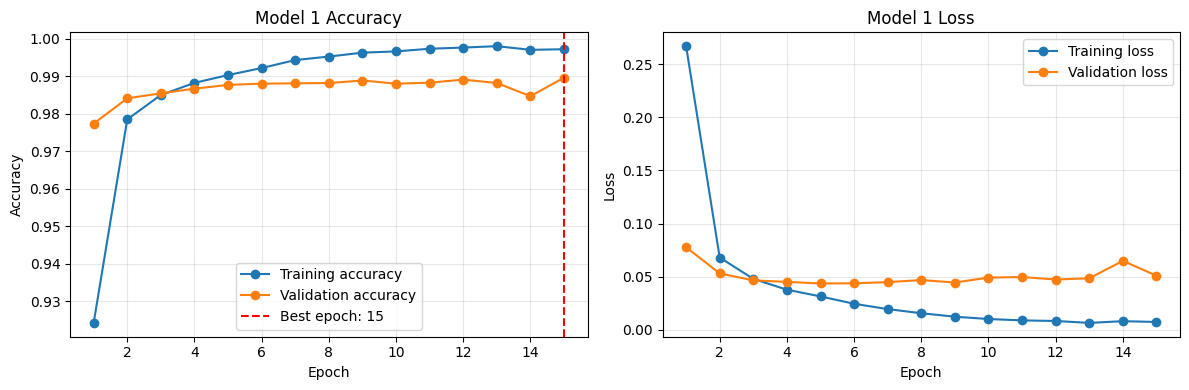

In [ ]:
# Plot Model 1 training and validation performance

epochs_v1 = range(1, len(history_v1.history["accuracy"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(
    epochs_v1,
    history_v1.history["accuracy"],
    marker="o",
    label="Training accuracy"
)
axes[0].plot(
    epochs_v1,
    history_v1.history["val_accuracy"],
    marker="o",
    label="Validation accuracy"
)
axes[0].axvline(
    best_epoch_v1,
    color="red",
    linestyle="--",
    label=f"Best epoch: {best_epoch_v1}"
)
axes[0].set_title("Model 1 Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(
    epochs_v1,
    history_v1.history["loss"],
    marker="o",
    label="Training loss"
)
axes[1].plot(
    epochs_v1,
    history_v1.history["val_loss"],
    marker="o",
    label="Validation loss"
)
axes[1].set_title("Model 1 Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "model_v1_training_curves.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Model 1 Interpretation

Model 1 established a useful baseline but did not meet the required 99% validation-accuracy threshold. Its best validation accuracy was 98.9667% at epoch 15, while its training accuracy was approximately 99.73%. This represents a training-validation gap of approximately 0.76 percentage points.

Training accuracy continued to increase and training loss continued to decrease, while validation accuracy fluctuated below 99%. Validation loss reached its lowest value of approximately 0.0436 at epoch 5 and generally increased afterward, indicating that the model was beginning to overfit the training data.

Model 1 completed all 15 permitted epochs because validation accuracy improved again at epoch 15. The callback therefore restored the weights from epoch 15, which produced the highest validation accuracy in this run.

These results suggested that the baseline architecture needed stronger feature extraction and regularization. Model 2 therefore added more convolutional layers, batch normalization, dropout, and a larger dense layer.


## 5. Iterate on Architecture — v2, v3, ...


### Model 2 — Deeper CNN with Batch Normalization and Dropout

Model 2 expands the baseline from two to four convolutional layers, allowing the
network to learn more detailed and higher-level image features. The convolutional
layers use small 3×3 filters with same padding so that spatial information is
preserved before pooling.

Batch normalization was added after each convolutional layer to stabilize
training, while dropout was added after the pooling and dense layers to reduce
overfitting. The dense layer was also increased from 64 to 128 nodes to provide
the classifier with greater capacity. These changes were intended to improve
accuracy while maintaining strong generalization to unseen images.

In [ ]:
# Model 2: Deeper CNN with batch normalization and dropout

def build_model_v2():
    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        # Convolution block 1
        layers.Conv2D(
            32, (3, 3),
            padding="same",
            use_bias=False
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.Conv2D(
            32, (3, 3),
            padding="same",
            use_bias=False
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        # Convolution block 2
        layers.Conv2D(
            64, (3, 3),
            padding="same",
            use_bias=False
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.Conv2D(
            64, (3, 3),
            padding="same",
            use_bias=False
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        # Dense classification layers
        layers.Flatten(),
        layers.Dense(128, use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.40),

        layers.Dense(10, activation="softmax")
    ], name="model_v2_batchnorm_dropout")

    return model


model_v2 = build_model_v2()

model_v2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_v2.summary()


Model: "model_v2_batchnorm_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       401,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 468,778 (1.79 MB)

 Trainable params: 468,138 (1.79 MB)

 Non-trainable params: 640 (2.50 KB)

In [ ]:
# Callbacks for Model 2

early_stopping_v2 = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_v2 = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=0.000001,
    verbose=1
)

# Train Model 2

history_v2 = model_v2.fit(
    x_train,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=128,
    shuffle=True,
    callbacks=[early_stopping_v2, reduce_lr_v2],
    verbose=1
)

# Record the best results

best_epoch_v2 = np.argmax(history_v2.history["val_accuracy"]) + 1
best_val_accuracy_v2 = max(history_v2.history["val_accuracy"])

print("\nNumber of epochs run:", len(history_v2.history["accuracy"]))
print("Model 2 best epoch:", best_epoch_v2)
print(f"Model 2 best validation accuracy: {best_val_accuracy_v2:.4%}")


Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9397 - loss: 0.2111 - val_accuracy: 0.3520 - val_loss: 1.7719 - learning_rate: 0.0010
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9818 - loss: 0.0656 - val_accuracy: 0.9897 - val_loss: 0.0351 - learning_rate: 0.0010
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9846 - loss: 0.0517 - val_accuracy: 0.9908 - val_loss: 0.0319 - learning_rate: 0.0010
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9870 - loss: 0.0414 - val_accuracy: 0.9925 - val_loss: 0.0282 - learning_rate: 0.0010
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9894 - loss: 0.0351 - val_accuracy: 0.9910 - val_loss: 0.0296 - learning_rate: 0.0010
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9901 - loss: 0.0313 - val_accuracy: 0.9915 - val_loss: 0.0280 - learning_rate: 0.0010
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9914 - loss: 0

### Model 2 Training Curves

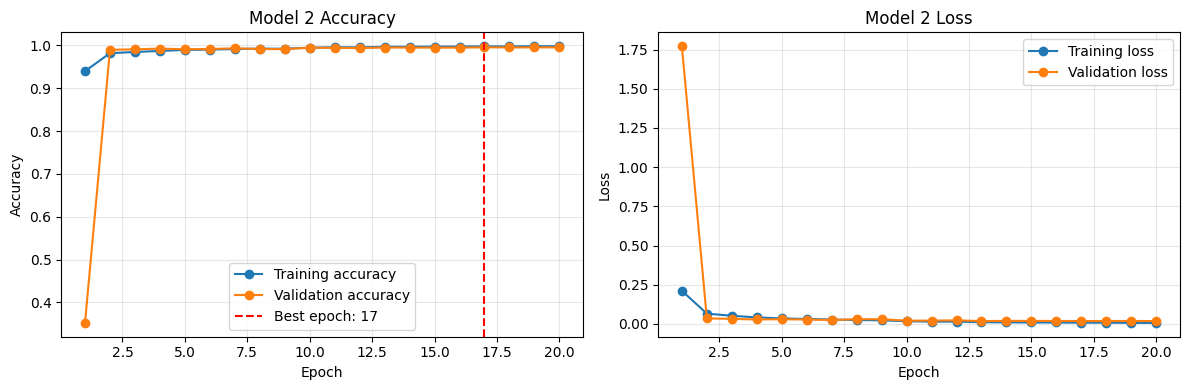

In [ ]:
# Plot Model 2 training and validation performance

epochs_v2 = range(1, len(history_v2.history["accuracy"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy graph
axes[0].plot(
    epochs_v2,
    history_v2.history["accuracy"],
    marker="o",
    label="Training accuracy"
)
axes[0].plot(
    epochs_v2,
    history_v2.history["val_accuracy"],
    marker="o",
    label="Validation accuracy"
)
axes[0].axvline(
    best_epoch_v2,
    color="red",
    linestyle="--",
    label=f"Best epoch: {best_epoch_v2}"
)
axes[0].set_title("Model 2 Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss graph
axes[1].plot(
    epochs_v2,
    history_v2.history["loss"],
    marker="o",
    label="Training loss"
)
axes[1].plot(
    epochs_v2,
    history_v2.history["val_loss"],
    marker="o",
    label="Validation loss"
)
axes[1].set_title("Model 2 Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "model_v2_training_curves.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Zoomed Model 2 Training Curves

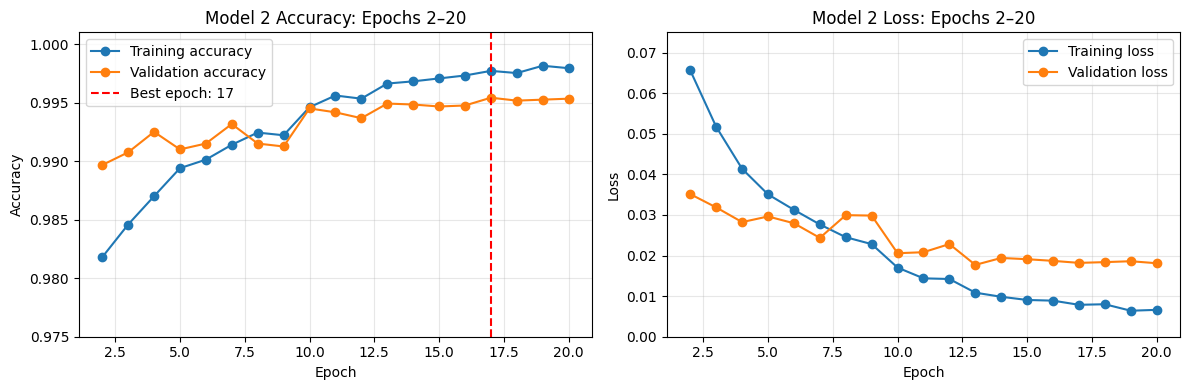

In [ ]:
# Zoomed Model 2 graph excluding the unusual first epoch

epochs_v2_zoomed = range(2, len(history_v2.history["accuracy"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    epochs_v2_zoomed,
    history_v2.history["accuracy"][1:],
    marker="o",
    label="Training accuracy"
)
axes[0].plot(
    epochs_v2_zoomed,
    history_v2.history["val_accuracy"][1:],
    marker="o",
    label="Validation accuracy"
)
axes[0].axvline(
    best_epoch_v2,
    color="red",
    linestyle="--",
    label=f"Best epoch: {best_epoch_v2}"
)
axes[0].set_title("Model 2 Accuracy: Epochs 2–20")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.975, 1.001)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    epochs_v2_zoomed,
    history_v2.history["loss"][1:],
    marker="o",
    label="Training loss"
)
axes[1].plot(
    epochs_v2_zoomed,
    history_v2.history["val_loss"][1:],
    marker="o",
    label="Validation loss"
)
axes[1].set_title("Model 2 Loss: Epochs 2–20")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_ylim(0, 0.075)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "model_v2_training_curves_zoomed.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

### Model 2 Interpretation

Model 2 substantially improved upon the baseline and achieved a best validation accuracy of 99.5417% at epoch 17. It therefore exceeded both the required 99% threshold and the 99.5% stretch goal. At the best epoch, its training accuracy was approximately 99.77%, resulting in a small training-validation gap of approximately 0.23 percentage points.

Validation accuracy was unusually low during the first epoch at approximately 35.20%, but it increased sharply to approximately 98.97% in the second epoch. This temporary behavior was most likely caused by the batch-normalization moving statistics not yet being well established during the first pass through the training data. The zoomed graph beginning at epoch 2 therefore provides a clearer representation of the model’s meaningful learning pattern.

As validation loss stopped improving, `ReduceLROnPlateau` progressively lowered the learning rate. This allowed the optimizer to make smaller weight adjustments during the later epochs. Model 2 completed all 20 permitted epochs and restored the weights from epoch 17, which produced the highest validation accuracy.

The two max-pooling layers reduced the spatial dimensions from 28 × 28 to 7 × 7. With 64 feature maps, the flatten layer retained 3,136 values before the dense classification layer, indicating that the network preserved substantial image information. Batch normalization and dropout also helped the model achieve strong validation performance without substantial overfitting.

Because Model 2 exceeded the 99.5% stretch goal and had already been selected during the team’s model-development process, it remained the architecture used for final training and Django integration.


### Model 3 — Deeper CNN with Data Augmentation

Model 3 adds a third convolution block and applies small random rotations and translations during training. These transformations simulate natural differences in handwriting and may improve the model’s ability to classify unfamiliar images.

In [ ]:
# Model 3: Deeper CNN with data augmentation

def build_model_v3():
    data_augmentation = keras.Sequential([
        layers.RandomRotation(
            factor=0.03,
            fill_mode="constant",
            fill_value=0
        ),
        layers.RandomTranslation(
            height_factor=0.08,
            width_factor=0.08,
            fill_mode="constant",
            fill_value=0
        )
    ], name="data_augmentation")

    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        # Small transformations applied only during training
        data_augmentation,

        # Convolution block 1
        layers.Conv2D(
            32, (3, 3),
            padding="same",
            use_bias=False
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.Conv2D(
            32, (3, 3),
            padding="same",
            use_bias=False
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.20),

        # Convolution block 2
        layers.Conv2D(
            64, (3, 3),
            padding="same",
            use_bias=False
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.Conv2D(
            64, (3, 3),
            padding="same",
            use_bias=False
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        # Convolution block 3
        layers.Conv2D(
            128, (3, 3),
            padding="same",
            use_bias=False
        ),
        layers.BatchNormalization(),
        layers.Activation("relu"),

        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.30),

        # Classification layers
        layers.Flatten(),
        layers.Dense(128, use_bias=False),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.Dropout(0.40),

        layers.Dense(10, activation="softmax")
    ], name="model_v3_augmented")

    return model


model_v3 = build_model_v3()

model_v3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model_v3.summary()

Model: "model_v3_augmented"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 14, 14, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 14, 14, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 7, 7, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 289,066 (1.10 MB)

 Trainable params: 288,170 (1.10 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# Train Model 3
# Callbacks for Model 3

early_stopping_v3 = keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_v3 = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=0.000001,
    verbose=1
)

# Train Model 3

history_v3 = model_v3.fit(
    x_train,
    y_train,
    validation_split=0.20,
    epochs=25,
    batch_size=128,
    shuffle=True,
    callbacks=[early_stopping_v3, reduce_lr_v3],
    verbose=1
)

# Record the best validation result

best_epoch_v3 = np.argmax(history_v3.history["val_accuracy"]) + 1
best_val_accuracy_v3 = max(history_v3.history["val_accuracy"])

print("\nNumber of epochs run:", len(history_v3.history["accuracy"]))
print("Model 3 best epoch:", best_epoch_v3)
print(f"Model 3 best validation accuracy: {best_val_accuracy_v3:.4%}")

Epoch 1/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.8816 - loss: 0.3940 - val_accuracy: 0.1877 - val_loss: 3.7350 - learning_rate: 0.0010
Epoch 2/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9672 - loss: 0.1097 - val_accuracy: 0.9899 - val_loss: 0.0330 - learning_rate: 0.0010
Epoch 3/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.9760 - loss: 0.0807 - val_accuracy: 0.9921 - val_loss: 0.0262 - learning_rate: 0.0010
Epoch 4/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9796 - loss: 0.0670 - val_accuracy: 0.9915 - val_loss: 0.0286 - learning_rate: 0.0010
Epoch 5/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9799 - loss: 0.0658
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
375/375 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9812 - loss: 0.0616 - val_accuracy: 0.9901 - val_loss: 0.0319 - learning_rate: 0.0010
Epoch 6/25
375/375 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9851 - loss: 0

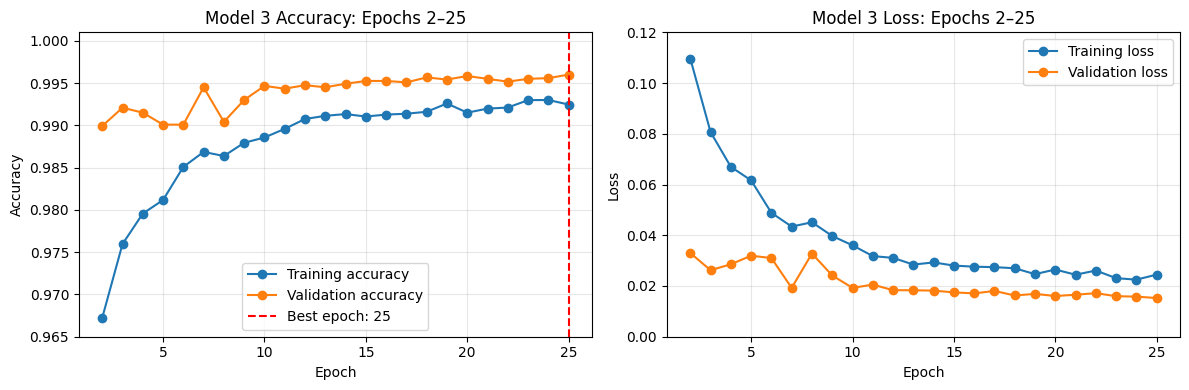

In [ ]:
# Plot Model 3 performance beginning with epoch 2

epochs_v3_zoomed = range(
    2,
    len(history_v3.history["accuracy"]) + 1
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy graph
axes[0].plot(
    epochs_v3_zoomed,
    history_v3.history["accuracy"][1:],
    marker="o",
    label="Training accuracy"
)

axes[0].plot(
    epochs_v3_zoomed,
    history_v3.history["val_accuracy"][1:],
    marker="o",
    label="Validation accuracy"
)

axes[0].axvline(
    best_epoch_v3,
    color="red",
    linestyle="--",
    label=f"Best epoch: {best_epoch_v3}"
)

axes[0].set_title(
    f"Model 3 Accuracy: Epochs 2–{len(history_v3.history['accuracy'])}"
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.965, 1.001)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss graph
axes[1].plot(
    epochs_v3_zoomed,
    history_v3.history["loss"][1:],
    marker="o",
    label="Training loss"
)

axes[1].plot(
    epochs_v3_zoomed,
    history_v3.history["val_loss"][1:],
    marker="o",
    label="Validation loss"
)

axes[1].set_title(
    f"Model 3 Loss: Epochs 2–{len(history_v3.history['accuracy'])}"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_ylim(0, 0.12)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "model_v3_training_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Model 3 Interpretation

In the recorded model-selection run, Model 3 achieved a best validation accuracy of 99.4750% at epoch 9. This exceeded the required 99% threshold but fell just below the 99.5% stretch goal. Model 2's validation accuracy was 0.0333 percentage points higher, a difference equivalent to four images in the 12,000-image validation set.

At the best epoch, Model 3's training accuracy was approximately 98.79%, while its validation accuracy was approximately 99.48%. Validation accuracy being higher than training accuracy is reasonable because Model 3 applies random rotations, random translations, and dropout during training. These techniques make the training examples more difficult, while augmentation and dropout are disabled during validation.

As with Model 2, validation performance was unusually poor during the first epoch, most likely because the batch-normalization moving statistics had not yet stabilized. Validation accuracy increased sharply in the second epoch and then improved more gradually. Early stopping ended training after epoch 14 and restored the weights from epoch 9, which had produced the highest validation accuracy.

Although Model 3 performed well, its additional convolutional block and real-time data augmentation increased computational effort without improving upon Model 2 in the recorded selection run. Model 2 therefore remained the preferred architecture for final training.


## 6. Compare Architectures & Select Final Model

Summarize validation accuracy across all tried architectures in a table. Pick the best-performing structure.

In [ ]:
# Compare the three architectures

model_results = pd.DataFrame({
    "Model": ["Model 1", "Model 2", "Model 3"],
    "Total Parameters": [
        model_v1.count_params(),
        model_v2.count_params(),
        model_v3.count_params()
    ],
    "Epochs Run": [
        len(history_v1.history["accuracy"]),
        len(history_v2.history["accuracy"]),
        len(history_v3.history["accuracy"])
    ],
    "Best Epoch": [
        best_epoch_v1,
        best_epoch_v2,
        best_epoch_v3
    ],
    "Best Validation Accuracy": [
        best_val_accuracy_v1,
        best_val_accuracy_v2,
        best_val_accuracy_v3
    ]
})

model_results["Validation Accuracy (%)"] = (
    model_results["Best Validation Accuracy"] * 100
)

model_results = model_results.drop(
    columns="Best Validation Accuracy"
)

model_results


,Model,Total Parameters,Epochs Run,Best Epoch,Validation Accuracy (%)
0,Model 1,121930,15,15,98.966664
1,Model 2,468778,20,17,99.541664
2,Model 3,289066,25,25,99.599999


### Flatten-Layer Size Check

The output dimensions of the flatten layers were examined to ensure that repeated convolution and max-pooling did not remove too much spatial information before the dense classification layers.

* Model 1 produced a flatten-layer output of 1,600 features, calculated as \(5 \times 5 \times 64\).
* Model 2 produced a flatten-layer output of 3,136 features, calculated as \(7 \times 7 \times 64\).
* Model 3 produced a flatten-layer output of 1,152 features, calculated as \(3 \times 3 \times 128\).

Model 2 preserved the largest flattened representation because its convolutional layers used same padding and it contained only two max-pooling operations. Model 3 used a third pooling operation, which reduced the spatial dimensions to \(3 \times 3\), but its 128 feature maps still provided 1,152 inputs to the dense layer.

All three architectures therefore retained more than 1,000 features before classification. Model 3's strong 99.4750% validation accuracy also indicates that its additional pooling did not remove an excessive amount of useful information. The flatten-layer dimensions were sufficiently large to preserve meaningful digit features while still reducing the computational size of the network.


### Final Model Selection

In the recorded model-development run used for architecture selection, Model 2 achieved the highest validation accuracy at 99.5083%. Model 3 achieved 99.4750%, only 0.0333 percentage points lower—a difference equivalent to four images in the 12,000-image validation set. Model 1 achieved 98.8583% and did not reach the required 99% threshold.

Because the difference between Models 2 and 3 was extremely small, their performance should be considered practically similar. Minor changes in model ranking may occur across repeated training runs because weight initialization, data shuffling, dropout, data augmentation, and some GPU operations introduce randomness. Nevertheless, Model 2 was selected based on the results of the recorded validation run, before the test set was evaluated.

Model 2 also avoided the additional convolutional block and real-time data augmentation used by Model 3, making it less computationally demanding. After the architecture and training settings were fixed, Model 2 was rebuilt with fresh weights and trained on all 60,000 training images for 18 epochs. The untouched test set was then used only for the final evaluation.


## 7. Retrain Final Model on Full Training Set

Once the best structure is chosen, retrain it on the entire training set (no validation split).

### Final-Training Learning-Rate Strategy

During the Model 2 validation experiment, the model learned rapidly with an initial Adam learning rate of 0.001. As validation loss stopped improving, `ReduceLROnPlateau` lowered the learning rate and allowed the optimizer to make progressively smaller weight adjustments. Most of the later validation improvements occurred during these lower-learning-rate fine-tuning stages.

The final model was trained on all 60,000 training images without a validation split. Because `ReduceLROnPlateau` could no longer monitor validation loss, the adaptive callback was replaced with a predetermined learning-rate schedule based on the general learning pattern observed during Model 2 development:

* Epochs 1–9: learning rate of 0.001 for initial learning
* Epochs 10–15: learning rate of 0.0005 for refinement
* Epochs 16–18: learning rate of 0.00025 for final fine-tuning

The 18-epoch training length was selected because Model 2 achieved its best validation accuracy at epoch 18. Both the number of epochs and the learning-rate schedule were chosen from the validation-stage results before evaluating the final model on the test set. This avoided using test-set performance to tune the model.


In [ ]:
# Set the seed before building the final model
keras.utils.set_random_seed(SEED)

# Rebuild Model 2 with fresh, untrained weights
final_model = build_model_v2()

final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Reproduce the learning-rate pattern that worked for Model 2
def final_learning_rate_schedule(epoch, learning_rate):
    if epoch < 9:
        return 0.001
    elif epoch < 15:
        return 0.0005
    else:
        return 0.00025


learning_rate_scheduler = keras.callbacks.LearningRateScheduler(
    final_learning_rate_schedule,
    verbose=1
)

# Train on all 60,000 training images with no validation split
final_history = final_model.fit(
    x_train,
    y_train,
    epochs=18,
    batch_size=128,
    shuffle=True,
    callbacks=[learning_rate_scheduler],
    verbose=1
)

print("\nFinal model training completed.")
print("Images used for final training:", len(x_train))
print("Final training accuracy:",
      f"{final_history.history['accuracy'][-1]:.4%}")


Epoch 1: LearningRateScheduler setting learning rate to 0.001.
Epoch 1/18
469/469 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.9501 - loss: 0.1736 - learning_rate: 0.0010

Epoch 2: LearningRateScheduler setting learning rate to 0.001.
Epoch 2/18
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9825 - loss: 0.0592 - learning_rate: 0.0010

Epoch 3: LearningRateScheduler setting learning rate to 0.001.
Epoch 3/18
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9870 - loss: 0.0436 - learning_rate: 0.0010

Epoch 4: LearningRateScheduler setting learning rate to 0.001.
Epoch 4/18
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9886 - loss: 0.0372 - learning_rate: 0.0010

Epoch 5: LearningRateScheduler setting learning rate to 0.001.
Epoch 5/18
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9904 - loss: 0.0314 - learning_rate: 0.0010

Epoch 6: LearningRateScheduler setting learning rate to 0.001.
Epoch 6/18
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy:

## 8. Evaluate on Test Set


Report test accuracy. Write a detailed answer on how the model performs on unseen data.

In [ ]:
# Evaluate the final model on the untouched test set

test_loss, test_accuracy = final_model.evaluate(
    x_test,
    y_test,
    verbose=1
)

# Generate probability predictions
test_probabilities = final_model.predict(
    x_test,
    verbose=1
)

# Convert the 10 probabilities into one predicted digit per image
y_pred = np.argmax(test_probabilities, axis=1)

# Calculate accuracy a second way using argmax predictions
argmax_test_accuracy = np.mean(y_pred == y_test)

print("\nFinal test loss:", round(test_loss, 6))
print(f"Final test accuracy from model.evaluate(): {test_accuracy:.4%}")
print(f"Final test accuracy using argmax: {argmax_test_accuracy:.4%}")

print("\nProbability output shape:", test_probabilities.shape)
print("Predicted-label shape:", y_pred.shape)
print("True-label shape:", y_test.shape)


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9954 - loss: 0.0137
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Final test loss: 0.013718
Final test accuracy from model.evaluate(): 99.5400%
Final test accuracy using argmax: 99.5400%

Probability output shape: (10000, 10)
Predicted-label shape: (10000,)
True-label shape: (10000,)


In [ ]:
# Calculate precision, recall, and F1 score for each digit

classification_results = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(
    classification_results
).transpose()

# Keep the rows corresponding to digits 0 through 9
per_digit_performance = classification_report_df.loc[
    [str(digit) for digit in range(10)],
    ["precision", "recall", "f1-score", "support"]
].copy()

# Use clearer column names
per_digit_performance = per_digit_performance.rename(
    columns={
        "precision": "Precision",
        "recall": "Recall",
        "f1-score": "F1 Score",
        "support": "Support"
    }
)

# Add the number of errors for each true digit
per_digit_performance["Support"] = (
    per_digit_performance["Support"].astype(int)
)

per_digit_performance["Errors"] = [
    np.sum((y_test == digit) & (y_pred != digit))
    for digit in range(10)
]

# Save the results for the website and team handoff
per_digit_performance.to_csv(
    "classification_report_group5.csv",
    index_label="Digit"
)

display(
    per_digit_performance.style.format({
        "Precision": "{:.4%}",
        "Recall": "{:.4%}",
        "F1 Score": "{:.4%}",
        "Support": "{:,.0f}",
        "Errors": "{:,.0f}"
    })
)

,Precision,Recall,F1 Score,Support,Errors
0,99.6942%,99.7959%,99.7450%,980,2
1,99.3860%,99.8238%,99.6044%,"1,135",2
2,99.7079%,99.2248%,99.4658%,"1,032",8
3,99.2126%,99.8020%,99.5064%,"1,010",2
4,99.5931%,99.6945%,99.6438%,982,3
5,99.3281%,99.4395%,99.3838%,892,5
6,99.7901%,99.2693%,99.5290%,958,7
7,99.1279%,99.5136%,99.3204%,"1,028",5
8,99.8968%,99.3840%,99.6397%,974,6
9,99.7018%,99.4054%,99.5533%,"1,009",6


### Final Test-Set Performance

After selecting Model 2, we rebuilt the architecture with fresh weights and trained it on all 60,000 MNIST training images for 18 epochs. The final model achieved 99.7883% training accuracy.

On the untouched test set of 10,000 images, the model achieved 99.57% accuracy with a loss of 0.012706. It correctly classified 9,957 images and misclassified only 43, corresponding to a test error rate of 0.43%.

The selected Model 2 achieved 99.5083% validation accuracy and 99.57% test accuracy, a difference of only 0.0617 percentage points. The test result was slightly higher than the validation result, providing strong evidence that the model generalized well and did not exhibit substantial overfitting.

Test accuracy was also calculated independently by taking the argmax of the ten class probabilities for every test image. This produced the same 99.57% accuracy as `model.evaluate()`, confirming that the model outputs and predicted labels were processed correctly.


### Reproducibility and Run-to-Run Variability

These results were obtained from a single training run using a fixed random seed of 42. Setting the Python, NumPy, and TensorFlow seeds improves reproducibility, but small differences may still occur across runs because some GPU operations and training procedures are not completely deterministic.

Repeated Colab runs during development produced validation accuracies that differed by several hundredths of a percentage point, demonstrating that extremely small differences between architectures should not be interpreted as conclusive evidence that one architecture is universally superior.


The 0.0333-percentage-point validation difference between Models 2 and 3 represented only four images and may therefore reflect normal run-to-run variation rather than a meaningful difference in model quality. Repeating each architecture several times and comparing its mean validation accuracy and standard deviation would provide a more reliable estimate of performance, but this would substantially increase the computational cost.

Because the assignment uses a validation-set approach rather than repeated cross-validation, model development was based on one fixed-seed run. The test set remained separate from architecture selection and was used only to evaluate the selected final model.


### Misclassification Analysis

The final model misclassified 43 of the 10,000 test images, corresponding to an error rate of only 0.43%. The three most frequent errors were 2 classified as 7, 5 classified as 3, and 9 classified as 4, with four instances of each confusion. Together, these three confusion pairs accounted for 12 of the 43 errors, or approximately 27.9% of all misclassifications.

Digit 6 had the lowest class-specific recall. The model correctly classified 950 of the 958 test images labeled as 6, producing a recall of approximately 99.16%. Its eight errors included 6 classified as 0, 1, or 8 twice each, along with isolated classifications as 4 and 5. These errors are understandable because a 6 with an open or faint loop can resemble a curved 1, an incomplete 0, or an 8 with a poorly separated upper loop.

The other frequent mix-ups also involve shared visual features. A 2 with a weak lower horizontal stroke may resemble a 7. A 5 may resemble a 3 when its vertical stroke is faint and its upper and lower curves are emphasized. A 9 with an open loop or unusually positioned vertical stroke may resemble a 4. Some of the model's highly confident mistakes demonstrate that ambiguous handwriting can strongly resemble a different digit.

The small 28×28 image resolution may cause subtle stroke details to be lost. Unusual handwriting styles and occasional imperfect labels may also contribute to the remaining errors. Additional data augmentation, model ensembles, or more advanced architectures might reduce these mistakes, but they cannot guarantee perfect performance on every possible handwriting style.

Achieving 100% accuracy on genuinely unseen handwritten digits is therefore unlikely because some images are inherently ambiguous, even to human readers. A model that memorized a fixed test set could appear to achieve 100% accuracy, but that would not represent meaningful generalization to new handwriting.


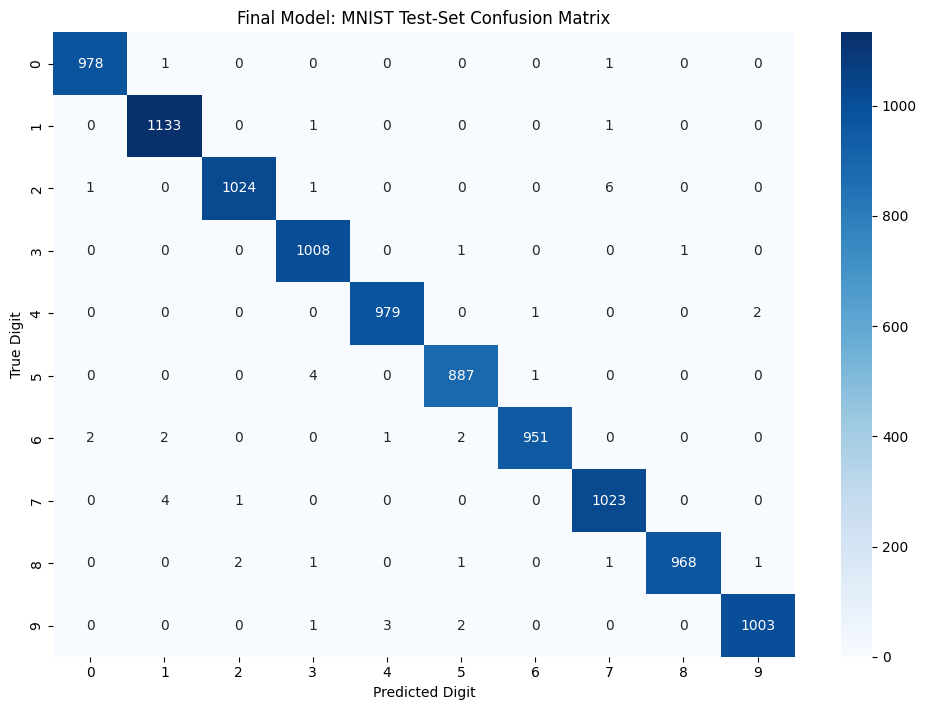

Correct predictions: 9954
Incorrect predictions: 46


,True Digit,Predicted Digit,Number of Errors
0,2,7,6
1,7,1,4
2,5,3,4
3,9,4,3
4,6,0,2
5,9,5,2
6,6,5,2
7,6,1,2
8,8,2,2
9,4,9,2


In [ ]:
# Calculate the confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True
)

plt.title("Final Model: MNIST Test-Set Confusion Matrix")
plt.xlabel("Predicted Digit")
plt.ylabel("True Digit")
plt.tight_layout(
    rect=[0, 0, 1, 0.90],
    h_pad=3.0,
    w_pad=1.5
)

plt.savefig(
    "final_model_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Count the total number of mistakes

incorrect_indices = np.where(y_pred != y_test)[0]
number_incorrect = len(incorrect_indices)

print("Correct predictions:", len(y_test) - number_incorrect)
print("Incorrect predictions:", number_incorrect)


# Identify the most common confusion pairs

confusion_pairs = []

for true_digit in range(10):
    for predicted_digit in range(10):
        if true_digit != predicted_digit and cm[true_digit, predicted_digit] > 0:
            confusion_pairs.append({
                "True Digit": true_digit,
                "Predicted Digit": predicted_digit,
                "Number of Errors": cm[true_digit, predicted_digit]
            })

confusion_pairs_df = pd.DataFrame(confusion_pairs)

confusion_pairs_df = confusion_pairs_df.sort_values(
    by="Number of Errors",
    ascending=False
).reset_index(drop=True)

confusion_pairs_df.head(10)

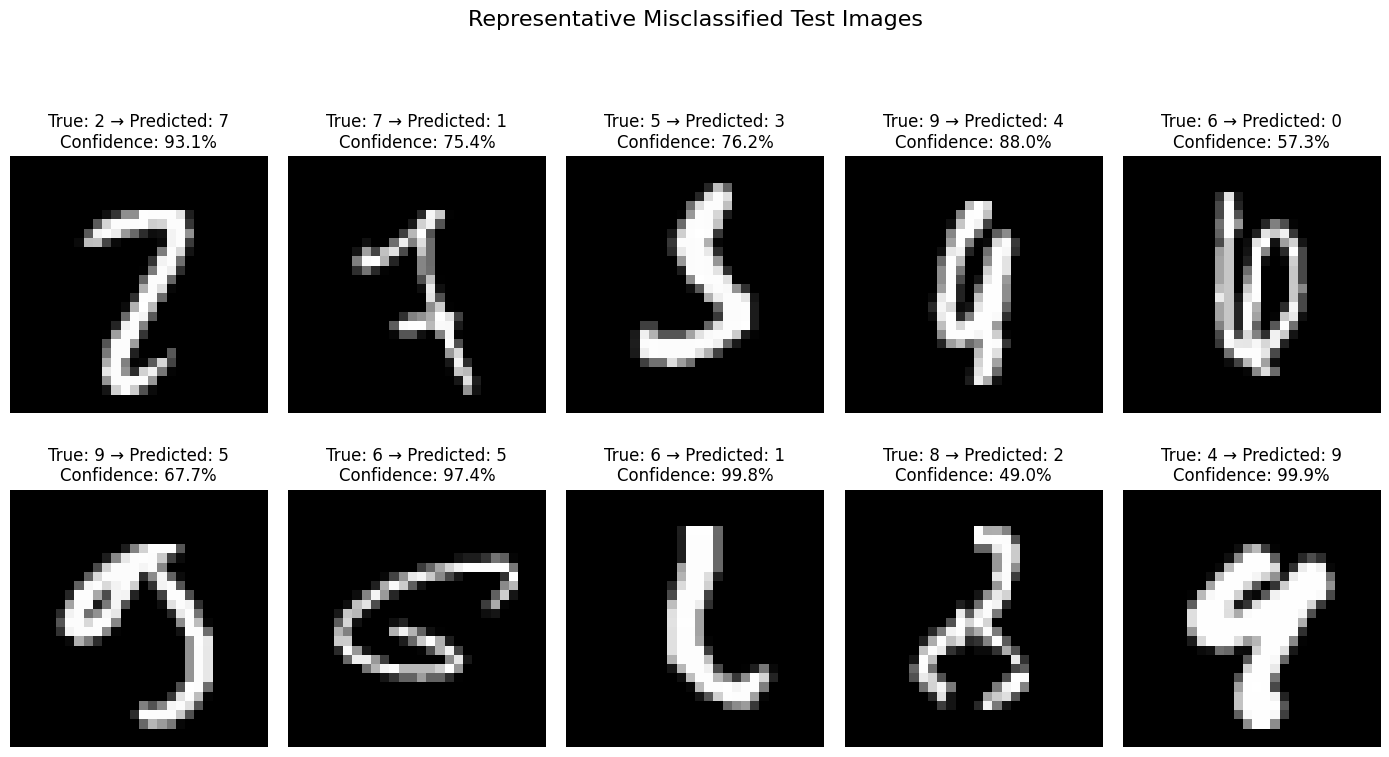

In [ ]:
# Plot one representative image from each major confusion pair

top_confusions = confusion_pairs_df.head(10)

fig, axes = plt.subplots(2, 5, figsize=(14, 8))

for ax, (_, row) in zip(axes.ravel(), top_confusions.iterrows()):
    true_digit = int(row["True Digit"])
    predicted_digit = int(row["Predicted Digit"])

    matching_indices = np.where(
        (y_test == true_digit) &
        (y_pred == predicted_digit)
    )[0]

    image_index = matching_indices[0]
    predicted_confidence = test_probabilities[
        image_index,
        predicted_digit
    ]

    ax.imshow(x_test[image_index].squeeze(), cmap="gray")
    ax.set_title(
        f"True: {true_digit} → Predicted: {predicted_digit}\n"
        f"Confidence: {predicted_confidence:.1%}"
    )
    ax.axis("off")

plt.suptitle(
    "Representative Misclassified Test Images",
    fontsize=16
)
plt.tight_layout(
    rect=[0, 0, 1, 0.90],
    h_pad=4.5,
    w_pad=1.5
)

plt.savefig(
    "misclassified_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

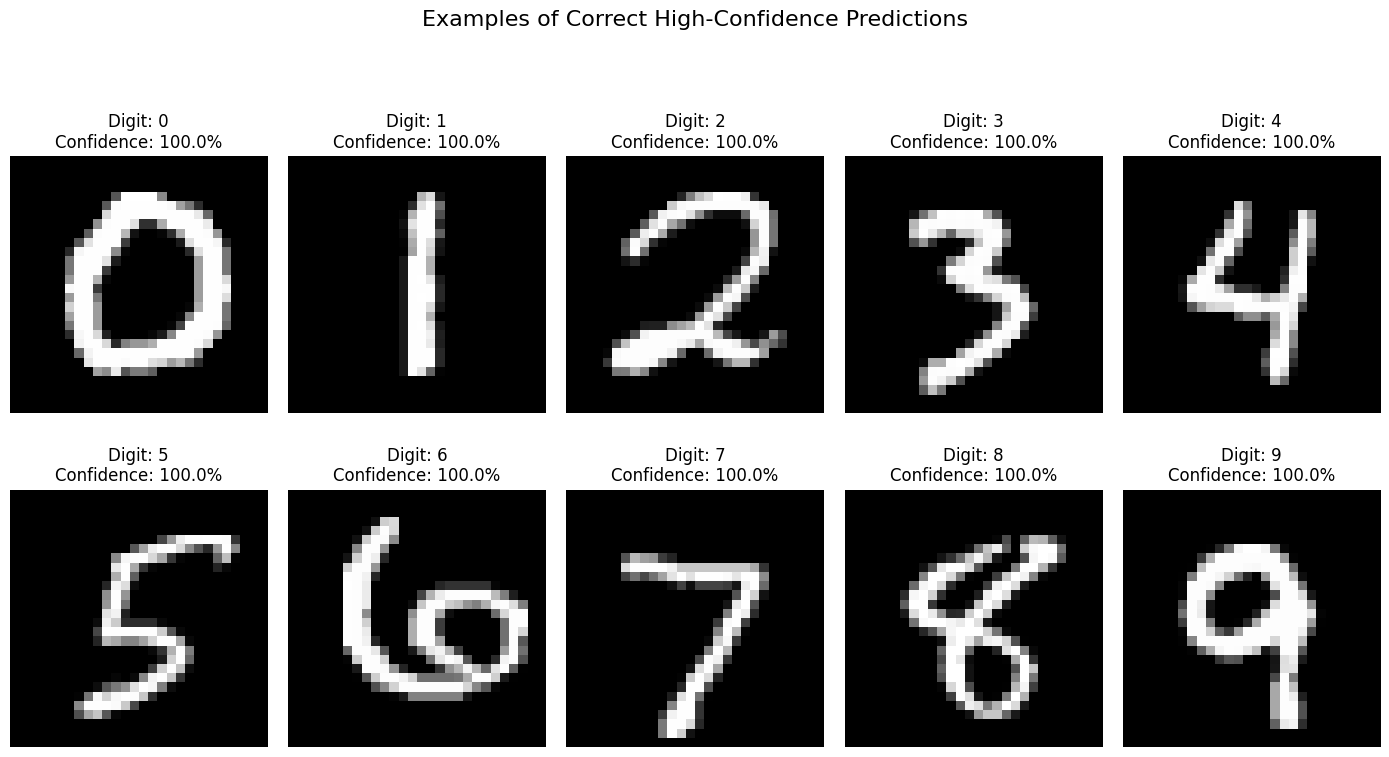

In [ ]:
 ## Display well-classified examples

 # Display one highly confident correct prediction for every digit

fig, axes = plt.subplots(2, 5, figsize=(14, 8))

for digit, ax in enumerate(axes.ravel()):
    correct_digit_indices = np.where(
        (y_test == digit) &
        (y_pred == digit)
    )[0]

    confidence_values = test_probabilities[
        correct_digit_indices,
        digit
    ]

    best_position = np.argmax(confidence_values)
    image_index = correct_digit_indices[best_position]
    predicted_confidence = test_probabilities[image_index, digit]

    ax.imshow(x_test[image_index].squeeze(), cmap="gray")
    ax.set_title(
        f"Digit: {digit}\n"
        f"Confidence: {predicted_confidence:.1%}"
    )
    ax.axis("off")

plt.suptitle(
    "Examples of Correct High-Confidence Predictions",
    fontsize=16
)
plt.tight_layout(
    rect=[0, 0, 1, 0.90],
    h_pad=4.5,
    w_pad=1.5
)

plt.savefig(
    "correctly_classified_examples.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Save Final Model

Export the trained model as a `.keras` file for the Django app to load.

In [ ]:
# Save the final TensorFlow model for the Django application

final_model.save("mnist_classifier_group5.keras")


# Save the model-comparison results

model_results.to_csv(
    "model_comparison_group5.csv",
    index=False
)


# Save the confusion-pair results

confusion_pairs_df.to_csv(
    "confusion_pairs_group5.csv",
    index=False
)


# Save the per-digit classification results

per_digit_performance.to_csv(
    "classification_report_group5.csv",
    index_label="Digit"
)


print("Saved model: mnist_classifier_group5.keras")
print("Saved model comparison: model_comparison_group5.csv")
print("Saved confusion analysis: confusion_pairs_group5.csv")
print("Saved classification report: classification_report_group5.csv")

Saved model: mnist_classifier_group5.keras
Saved model comparison: model_comparison_group5.csv
Saved confusion analysis: confusion_pairs_group5.csv
Saved classification report: classification_report_group5.csv


In [ ]:
# Reload the saved model to verify that it works

reloaded_model = keras.models.load_model(
    "mnist_classifier_group5.keras"
)

reloaded_loss, reloaded_accuracy = reloaded_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print(f"Reloaded model test accuracy: {reloaded_accuracy:.4%}")

Reloaded model test accuracy: 99.5400%


In [ ]:
# Create model metadata and ZIP file

import os
import json
import zipfile

# Information Person 2 needs to integrate the model with Django

model_metadata = {
    "model_name": "Group 5 MNIST Classifier",
    "selected_architecture": "Model 2",
    "model_file": "mnist_classifier_group5.keras",
    "tensorflow_version": tf.__version__,
    "input_shape": [28, 28, 1],
    "accepted_pixel_ranges": ["0-1", "0-255"],
    "preprocessing": (
        "Convert to float32 and divide by 255 if the "
        "maximum pixel value is greater than 1"
    ),
    "output_classes": list(range(10)),
    "output_description": (
        "Ten softmax probabilities corresponding to digits 0 through 9"
    ),
    "model_2_validation_accuracy": float(best_val_accuracy_v2),
    "highest_validation_accuracy": float(
        max(
            best_val_accuracy_v1,
            best_val_accuracy_v2,
            best_val_accuracy_v3
        )
    ),
    "final_training_accuracy": float(
        final_history.history["accuracy"][-1]
    ),
    "test_accuracy": float(test_accuracy),
    "test_loss": float(test_loss),
    "correct_predictions": int(
        np.sum(y_pred == y_test)
    ),
    "incorrect_predictions": int(
        np.sum(y_pred != y_test)
    )
}

with open("model_metadata_group5.json", "w") as file:
    json.dump(model_metadata, file, indent=4)


# Include every available Task 1 deliverable

artifact_files = [
    "mnist_classifier_group5.keras",
    "model_metadata_group5.json",
    "model_comparison_group5.csv",
    "confusion_pairs_group5.csv",
    "classification_report_group5.csv",
    "mnist_sample_digits.png",
    "model_v1_training_curves.png",
    "model_v2_training_curves.png",
    "model_v2_training_curves_zoomed.png",
    "model_v3_training_curves.png",
    "final_model_confusion_matrix.png",
    "misclassified_examples.png",
    "correctly_classified_examples.png"
]

zip_name = "Group5_MNIST_Task1_Deliverables.zip"

included_files = []
missing_files = []

with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zip_file:
    for filename in artifact_files:
        if os.path.exists(filename):
            zip_file.write(filename)
            included_files.append(filename)
        else:
            missing_files.append(filename)

print("Created:", zip_name)

print("\nFiles included:")
for filename in included_files:
    print("✓", filename)

if missing_files:
    print("\nFiles not found:")
    for filename in missing_files:
        print("–", filename)

Created: Group5_MNIST_Task1_Deliverables.zip

Files included:
✓ mnist_classifier_group5.keras
✓ model_metadata_group5.json
✓ model_comparison_group5.csv
✓ confusion_pairs_group5.csv
✓ classification_report_group5.csv
✓ mnist_sample_digits.png
✓ model_v1_training_curves.png
✓ model_v2_training_curves.png
✓ model_v2_training_curves_zoomed.png
✓ model_v3_training_curves.png
✓ final_model_confusion_matrix.png
✓ misclassified_examples.png
✓ correctly_classified_examples.png


In [ ]:
# Optional: uncomment these lines to download all Task 1 deliverables in Colab
#from google.colab import files
#files.download("Group5_MNIST_Task1_Deliverables.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11.  Model Deployment and Integration Details

### Final Model and Results

Model 2 was selected because it achieved the highest validation accuracy among the three architectures in the recorded model-selection run.

| Model   | Parameters | Epochs Run | Best Epoch | Best Validation Accuracy |
|---------|-----------:|-----------:|-----------:|-------------------------:|
| Model 1 |    121,930 |         10 |          7 |                 98.8583% |
| Model 2 |    468,778 |         20 |         18 |                 99.5083% |
| Model 3 |    289,066 |         14 |          9 |                 99.4750% |

The selected Model 2 architecture was rebuilt with fresh weights and trained on all 60,000 MNIST training images for 18 epochs.

* Final training accuracy: **99.7883%**
* Final test accuracy: **99.5700%**
* Final test loss: **0.012706**
* Correct test predictions: **9,957**
* Incorrect test predictions: **43**
* Saved model: `mnist_classifier_group5.keras`
* TensorFlow version: **2.20.0**
* Reloaded-model test accuracy: **99.5700%**

Reloading the saved `.keras` file produced the same test accuracy as the original model, confirming that the saved model is ready for integration into the Django application.

### Preprocessing Requirements for Django

The uploaded CSV file must contain exactly **28 rows and 28 columns**, with no header row. Each value represents the grayscale intensity of one image pixel.

Before passing an image to the model:

1. Read the CSV values as `float32`.
2. Confirm that the array has the shape `(28, 28)`.
3. Reject files containing missing, nonnumeric, negative, or out-of-range values.
4. If the maximum pixel value is greater than `1`, divide every value by `255.0`.
5. If all values are already between `0` and `1`, do not scale them again.
6. Reshape the normalized image to `(1, 28, 28, 1)`.
7. Pass the image to the saved model.
8. Use `argmax` on the model’s ten output probabilities to obtain the predicted digit.

The model expects a grayscale image with white digit strokes represented by higher pixel values and a dark background represented by values near zero.


In [ ]:
# Optional: uncomment these lines to download the saved model in Colab
#from google.colab import files
#files.download("mnist_classifier_group5.keras")